# 04 - Gradient descent
**Concepts: derivatives, gradients, gradient descent.**

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))  # make `src` importable from notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import load_houses, to_arrays, FEATURES, TARGET
from src.preprocessing import train_test_split, Standardizer, add_bias
from src.model import LinearRegression, mse, gradient, numerical_gradient, rmse, r2_score

## 1. A derivative is a slope
$f'(x)=\lim_{h\to0}\frac{f(x+h)-f(x-h)}{2h}$. For $f(x)=x^2$, $f'(x)=2x$.

In [2]:
f = lambda x: x ** 2
for x0 in (-3, 0, 2):
    h = 1e-6
    print(f'x={x0:>2}  numeric={(f(x0 + h) - f(x0 - h)) / (2 * h):+.4f}  analytic={2 * x0:+.4f}')

x=-3  numeric=-6.0000  analytic=-6.0000
x= 0  numeric=+0.0000  analytic=+0.0000
x= 2  numeric=+4.0000  analytic=+4.0000


## 2. Gradient descent on a 1-D function
Rule: $x \leftarrow x - \eta f'(x)$. Move against the slope to go downhill.

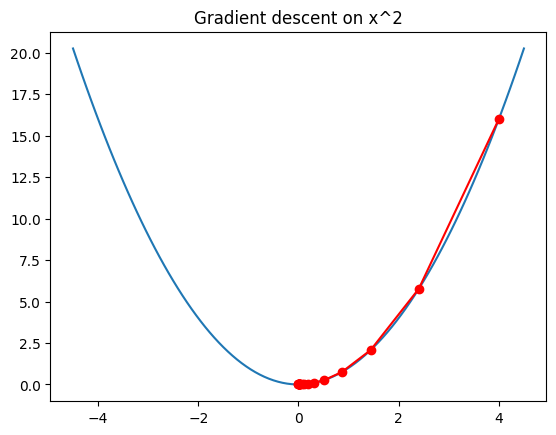

final x: 0.0001462463376025189


In [3]:
x, lr, path = 4.0, 0.2, []
for _ in range(20):
    path.append(x)
    x -= lr * 2 * x
grid = np.linspace(-4.5, 4.5, 100)
plt.plot(grid, f(grid)); plt.plot(path, [f(p) for p in path], 'o-', color='red')
plt.title('Gradient descent on x^2'); plt.show()
print('final x:', x)

## 3. Gradient of the MSE
$J(w)=\frac1m\sum_i (x_i\cdot w-y_i)^2$. Chain rule: $\frac{\partial J}{\partial w_j}=\frac2m\sum_i (x_i\cdot w-y_i)\,x_{ij}$.
Matrix form: $\nabla J=\frac2m X^T(Xw-y)$. We verify it against the numerical derivative.

In [4]:
df = load_houses()
X, y = to_arrays(df)
X_tr, X_te, y_tr, y_te = train_test_split(X, y)

xs, ys = Standardizer().fit(X_tr), Standardizer().fit(y_tr)
Z_tr, Z_te = xs.transform(X_tr), xs.transform(X_te)
yz_tr = ys.transform(y_tr)
Xb = add_bias(Z_tr)

w0 = np.random.default_rng(1).normal(size=Xb.shape[1])
print('analytic:', gradient(Xb, yz_tr, w0).round(6))
print('numeric :', numerical_gradient(Xb, yz_tr, w0).round(6))

analytic: [ 0.691168  0.104491  0.30313  -2.200734]
numeric : [ 0.691168  0.104491  0.30313  -2.200734]


## 4. Train with gradient descent

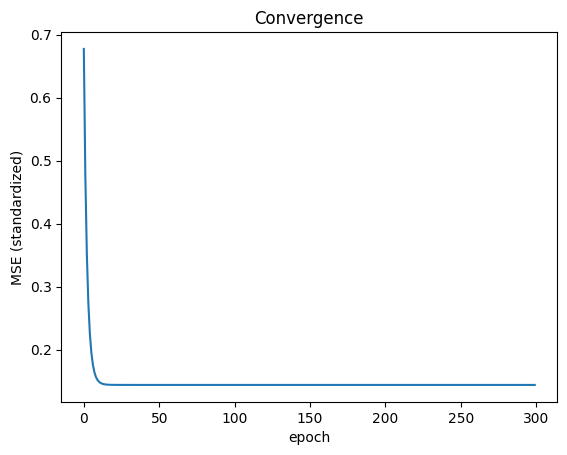

max |w_gd - w_normal| = 2.7755575615628914e-16
RMSE=15,167  R2=0.8039


In [5]:
gd = LinearRegression().fit_gd(Z_tr, yz_tr, lr=0.1, epochs=300)
ne = LinearRegression().fit_normal(Z_tr, yz_tr)

plt.plot(gd.loss_history); plt.xlabel('epoch'); plt.ylabel('MSE (standardized)')
plt.title('Convergence'); plt.show()

print('max |w_gd - w_normal| =', np.abs(gd.w - ne.w).max())
pred = ys.inverse_transform(gd.predict(Z_te))
print(f'RMSE={rmse(y_te, pred):,.0f}  R2={r2_score(y_te, pred):.4f}')

## 5. The learning rate matters
Too small: slow. Good: fast and stable. Too large: diverges.

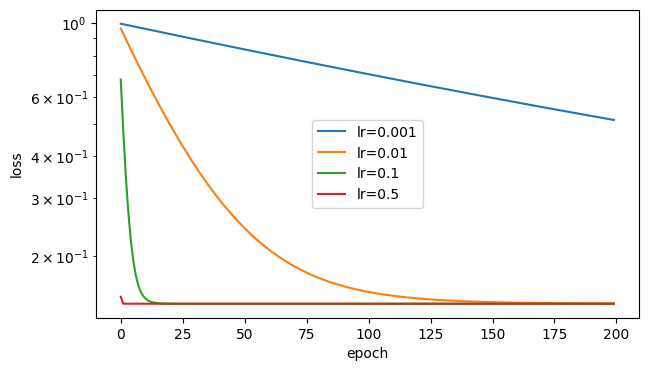

lr=1.1 loss after 30 epochs: 2.783e+08 (divergence)


In [6]:
plt.figure(figsize=(7, 4))
for lr in (0.001, 0.01, 0.1, 0.5):
    m = LinearRegression().fit_gd(Z_tr, yz_tr, lr=lr, epochs=200)
    plt.plot(m.loss_history, label=f'lr={lr}')
plt.yscale('log'); plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.show()

m = LinearRegression().fit_gd(Z_tr, yz_tr, lr=1.1, epochs=30)
print('lr=1.1 loss after 30 epochs:', f'{m.loss_history[-1]:.3e}', '(divergence)')

## 6. Why standardize? Gradient descent on raw features

In [7]:
yc = (y_tr - y_tr.mean()) / y_tr.std()   # only center/scale the target
for lr in (1e-3, 1e-5):
    with np.errstate(all='ignore'):
        m = LinearRegression().fit_gd(X_tr, yc, lr=lr, epochs=500)
    print(f'raw features, lr={lr:g}: final loss = {m.loss_history[-1]:.4g}')
print('standardized, lr=0.1  : final loss =', f'{gd.loss_history[-1]:.4g}')
print('\nFeatures on very different scales (size ~100, bedrooms ~3) make the loss surface a narrow valley:\nno single learning rate '
      'works well for all weights.')

raw features, lr=0.001: final loss = nan
raw features, lr=1e-05: final loss = 0.5501
standardized, lr=0.1  : final loss = 0.1442

Features on very different scales (size ~100, bedrooms ~3) make the loss surface a narrow valley:
no single learning rate works well for all weights.


## 7. Mini-batch and stochastic gradient descent (SGD)
Full-batch GD uses **all** rows for one update. Mini-batch SGD shuffles the rows each epoch, cuts them into batches, and updates after **each batch**: the gradient is noisier but far cheaper, so there are many more updates per epoch.

- `batch_size = len(y)` -> plain gradient descent
- `batch_size = 1` -> pure stochastic GD
- in between -> mini-batch (the standard choice)

Batch GD (lr=0.1)          updates/epoch=  1  final loss=0.1442
Mini-batch 32 (lr=0.02)    updates/epoch= 13  final loss=0.1443
SGD batch=1 (lr=0.005)     updates/epoch=400  final loss=0.1466


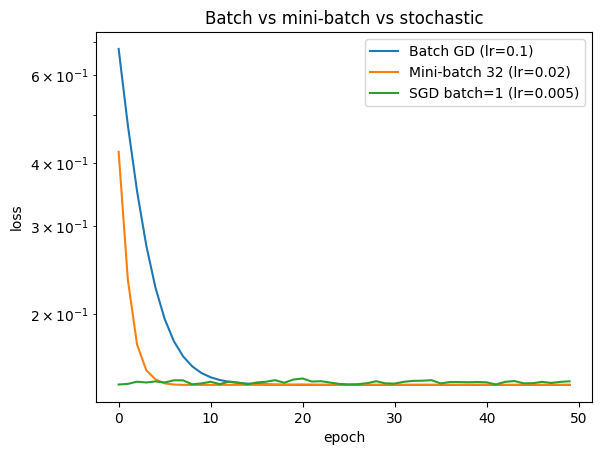

In [8]:
runs = {
    'Batch GD (lr=0.1)':        LinearRegression().fit_gd(Z_tr, yz_tr, lr=0.1, epochs=50),
    'Mini-batch 32 (lr=0.02)':  LinearRegression().fit_sgd(Z_tr, yz_tr, lr=0.02, epochs=50, batch_size=32),
    'SGD batch=1 (lr=0.005)':   LinearRegression().fit_sgd(Z_tr, yz_tr, lr=0.005, epochs=50, batch_size=1),
}
updates = {'Batch GD (lr=0.1)': 1, 'Mini-batch 32 (lr=0.02)': int(np.ceil(len(yz_tr) / 32)), 'SGD batch=1 (lr=0.005)': len(yz_tr)}
for name, m in runs.items():
    print(f'{name:26s} updates/epoch={updates[name]:>3}  final loss={m.loss_history[-1]:.4f}')
    plt.plot(m.loss_history, label=name)
plt.yscale('log'); plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.title('Batch vs mini-batch vs stochastic'); plt.show()

In [9]:
# Sanity check: batch_size = number of rows is exactly full-batch GD
a = LinearRegression().fit_sgd(Z_tr, yz_tr, lr=0.1, epochs=200, batch_size=len(yz_tr))
b = LinearRegression().fit_gd(Z_tr, yz_tr, lr=0.1, epochs=200)
print('max |w_sgd(bs=m) - w_gd| =', np.abs(a.w - b.w).max())

max |w_sgd(bs=m) - w_gd| = 2.7755575615628914e-17


**Reading the plot:** per epoch, SGD makes progress much faster because it updates 400 times instead of once. Its curve is jagged because each batch gives a noisy estimate of the true gradient, and it hovers near the minimum instead of settling exactly on it.

## 8. Ridge regression (L2 regularization)
Add a penalty on large weights: $J(w)=\frac1m\|Xw-y\|^2+\lambda\|w\|^2$.

Differentiating the penalty: $\frac{\partial}{\partial w_j}\lambda w_j^2 = 2\lambda w_j$, so $\nabla J=\frac2m X^T(Xw-y)+2\lambda w$.

The bias is **not** penalized (shifting all prices up should cost nothing). Closed form: $(X^TX + m\lambda P)\,w = X^Ty$, where $P$ is the identity with a 0 for the bias.

In [10]:
# 1. Gradient check with the penalty
lam = 0.3
print('analytic:', gradient(Xb, yz_tr, w0, l2=lam).round(6))
print('numeric :', numerical_gradient(Xb, yz_tr, w0, l2=lam).round(6))

# 2. Gradient descent and the closed form agree again
r_gd = LinearRegression().fit_gd(Z_tr, yz_tr, lr=0.1, epochs=800, l2=lam)
r_ne = LinearRegression().fit_normal(Z_tr, yz_tr, l2=lam)
print('max |w_gd - w_normal| =', np.abs(r_gd.w - r_ne.w).max())

analytic: [ 0.691168  0.597462  0.501392 -2.982628]
numeric : [ 0.691168  0.597462  0.501392 -2.982628]
max |w_gd - w_normal| = 1.5265566588595902e-16


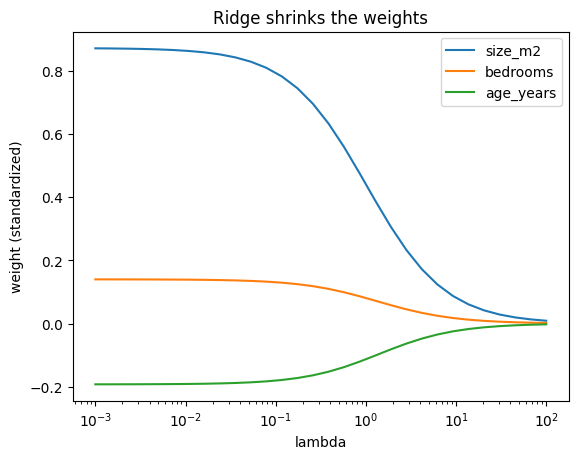

In [11]:
# 3. Shrinkage: weights move toward 0 as lambda grows
lams = np.logspace(-3, 2, 30)
W = np.array([LinearRegression().fit_normal(Z_tr, yz_tr, l2=l).w[1:] for l in lams])
for j, name in enumerate(FEATURES):
    plt.plot(lams, W[:, j], label=name)
plt.xscale('log'); plt.xlabel('lambda'); plt.ylabel('weight (standardized)'); plt.legend(); plt.title('Ridge shrinks the weights'); plt.show()

### When does Ridge actually help?
With 400 rows and 3 features, plain regression is already stable, so Ridge changes little. Ridge pays off when data is **scarce or noisy** (high variance). Test: train on only 12 houses, repeat with 30 different random subsets, and average the test error.

lambda=0     mean test RMSE = 17,555
lambda=0.01  mean test RMSE = 17,455
lambda=0.1   mean test RMSE = 17,304
lambda=0.3   mean test RMSE = 18,567
lambda=1     mean test RMSE = 23,192
lambda=3     mean test RMSE = 28,778


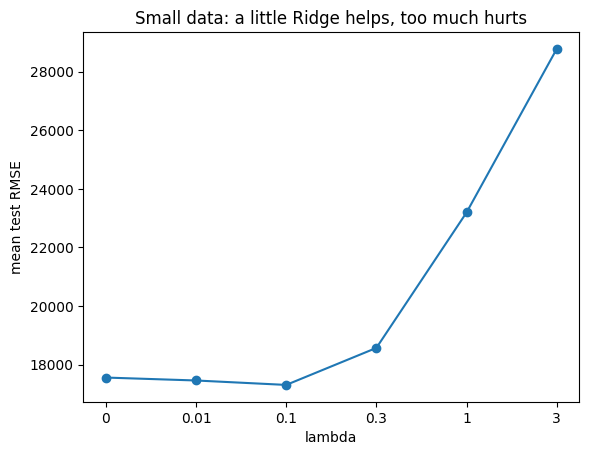

In [12]:
rng_lams = [0, 0.01, 0.1, 0.3, 1, 3]
Z_te = xs.transform(X_te)
mean_rmse = []
for l in rng_lams:
    errs = []
    for seed in range(30):
        idx = np.random.default_rng(seed).choice(len(Z_tr), 12, replace=False)
        m = LinearRegression().fit_normal(Z_tr[idx], yz_tr[idx], l2=l)
        errs.append(rmse(y_te, ys.inverse_transform(m.predict(Z_te))))
    mean_rmse.append(np.mean(errs))
    print(f'lambda={l:<5} mean test RMSE = {mean_rmse[-1]:,.0f}')
plt.plot(range(len(rng_lams)), mean_rmse, 'o-'); plt.xticks(range(len(rng_lams)), rng_lams)
plt.xlabel('lambda'); plt.ylabel('mean test RMSE'); plt.title('Small data: a little Ridge helps, too much hurts'); plt.show()

**Takeaway:** a small $\lambda$ trades a little bias for lower variance and reduces test error. A large $\lambda$ forces the weights toward 0 and underfits. Choosing $\lambda$ is done with a validation set.

## 9. A real dataset: California Housing
Same code, real data: 20,640 districts, 8 features (median income, house age, rooms, latitude, ...), target in units of \$100,000.
It downloads once via scikit-learn (internet needed), then runs the whole pipeline. Or from the terminal:

```bash
python -m src.train --dataset california --l2 0.01
```

In [ ]:
from src.data import load_california, CALIFORNIA_TARGET

cal = load_california()
Xc, yc = to_arrays(cal, CALIFORNIA_TARGET)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc)
xs_c, ys_c = Standardizer().fit(Xc_tr), Standardizer().fit(yc_tr)
Zc_tr, Zc_te = xs_c.transform(Xc_tr), xs_c.transform(Xc_te)

for l in (0, 0.01, 0.1):
    m = LinearRegression().fit_normal(Zc_tr, ys_c.transform(yc_tr), l2=l)
    p = ys_c.inverse_transform(m.predict(Zc_te))
    print(f'lambda={l:<5} RMSE={rmse(yc_te, p):.3f} (x $100k)  R2={r2_score(yc_te, p):.3f}')
cal.head()

**Things to notice on real data:** R² is lower than on our synthetic data (the true relationship isn't perfectly linear, and prices are capped at \$500k), some features like `AveRooms` and `Population` have extreme outliers, and `Latitude`/`Longitude` are strongly correlated with each other. Real data is where standardization and Ridge start to matter.